In [113]:
import scipy as sp
from scipy.special import jv, hankel1, hankel2, yv, yvp, jvp
import numpy as np
import matplotlib.pyplot as plt
from numpy import sqrt, linspace, zeros, ones, argmin, log, unravel_index, pi, array, einsum, angle
from utils import hl1_prime, hl2_prime, h_z_cpa_numerator, h_z_cpa, e_z_cpa, h_z_recursive_cpa, e_z_recursive_cpa

In [114]:
M = 1000
epsilon = 1
x = linspace(0.001, 1, M) # Free space kR
m = sqrt(epsilon)
y = x * m # epsilonkR in the cylinder

In [115]:
l = 1
j_y = jv(l, y); 
y_x = yv(l, x); 
j_yprime = jvp(l, y);
y_xprime = yvp(l, x)
sigmas = 1j*(m*j_y/j_yprime - y_x/y_xprime)
sigmas_real = sigmas.real
sigmas_imaginary = sigmas.imag
s_s = h_z_cpa(l, x, epsilon, -1j*(sigmas_real + 1j*sigmas_imaginary))

### We sweep the imaginary part of the conductivity through the point at which $s=-1$

In [122]:
x_idx = 200
N = 10000
sigmas_off_passive_sink = 1j*linspace(1/2, 1.5, N) * sigmas_imaginary[x_idx]
s_off_passive_sink = h_z_cpa(l, x[x_idx], epsilon, -1j*sigmas_off_passive_sink)

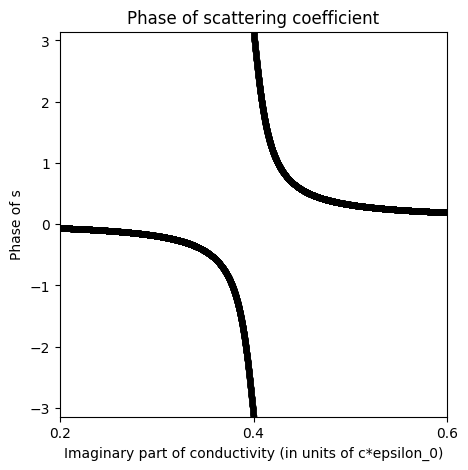

In [124]:
fig, ax = plt.subplots(figsize=(5, 5))
sigmas_off_passive_sink_imag = sigmas_off_passive_sink.imag
min_x = sigmas_off_passive_sink_imag.min()
max_x = sigmas_off_passive_sink_imag.max()
ax.scatter(sigmas_off_passive_sink_imag, angle(s_off_passive_sink), color="black", s=10)
ax.set_xlim(min_x, max_x)
ax.set_ylim(-pi, pi)
ax.set_xlabel("Imaginary part of conductivity (in units of c*epsilon_0)");
ax.set_ylabel("Phase of s");
ax.set_xticks([min_x, (min_x+max_x)/2, max_x], np.round([min_x, (min_x+max_x)/2, max_x], 1));
ax.set_title("Phase of scattering coefficient");

### Now we plot $s$ as a the real part of the surface conductivity is sweeped. We expect that $|s|<1$ throughout the range due to absorption.

In [174]:
x_idx = 100
N = 10000
sigmas_off_passive_sink = linspace(0, 0.005, N) + 1j*sigmas_imaginary[x_idx]
s_off_passive_sink = h_z_cpa(l, x[x_idx], epsilon, -1j*sigmas_off_passive_sink)

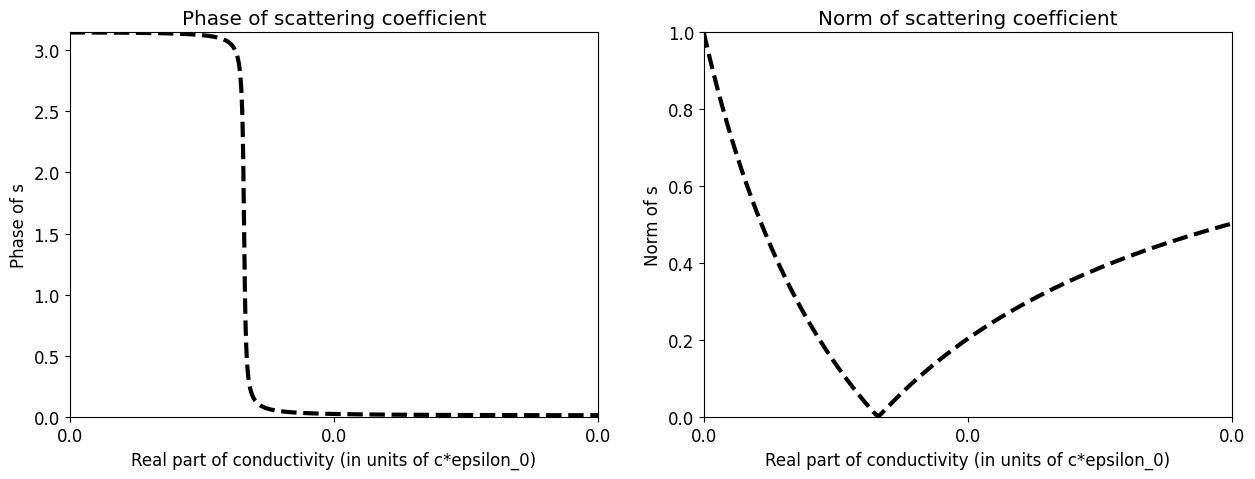

In [176]:
plt.rcParams.update({'font.size': 12})
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
sigmas_off_passive_sink_real = sigmas_off_passive_sink.real
min_x = sigmas_off_passive_sink_real.min()
max_x = sigmas_off_passive_sink_real.max()
ax1.plot(sigmas_off_passive_sink_real, angle(s_off_passive_sink), color="black", linestyle="dashed", linewidth=3)
ax1.set_xlim(min_x, max_x)
ax1.set_ylim(0, pi)
ax1.set_xlabel("Real part of conductivity (in units of c*epsilon_0)");
ax1.set_ylabel("Phase of s");
ax1.set_xticks([min_x, (min_x+max_x)/2, max_x], np.round([min_x, (min_x+max_x)/2, max_x], 1));
ax1.set_title("Phase of scattering coefficient");

ax2.plot(sigmas_off_passive_sink_real, np.abs(s_off_passive_sink), color="black", linestyle="dashed", linewidth=3)
ax2.set_xlim(min_x, max_x)
ax2.set_ylim(0, 1)
ax2.set_xlabel("Real part of conductivity (in units of c*epsilon_0)");
ax2.set_ylabel("Norm of s");
ax2.set_xticks([min_x, (min_x+max_x)/2, max_x], np.round([min_x, (min_x+max_x)/2, max_x], 1));
ax2.set_title("Norm of scattering coefficient");